In [4]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tableone)
library(caret)
library(broom)
install.packages("tableone")
library(tableone)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lattice

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [5]:
# Import ICU data
icu_data <- readRDS("icu_data_.rds")

The analysis uses a dataset that was constructed previously containing demographic, physiological and laboratory variables extracted from MIMIC-III. The data extraction was performed in a separate step to ensure clear separation between the analysis and preprocessing.

## 2. Inspection of the dataset

An initial inspection was performed in order check wether the structure, variable types and overall dimensions of the dataset are correct, before proceeding further.

In [6]:
dim(icu_data)
colnames(icu_data)
str(icu_data)

[1] 32000    31

[1] "subject_id"           "hadm_id"              "icustay_id"          
 [4] "intime"               "gender"               "age"                 
 [7] "hospital_expire_flag" "hr_mean"              "hr_min"              
[10] "hr_max"               "map_mean"             "map_min"             
[13] "map_max"              "rr_mean"              "rr_min"              
[16] "rr_max"               "spo2_mean"            "spo2_min"            
[19] "spo2_max"             "temp_mean"            "temp_min"            
[22] "temp_max"             "lactate_mean"         "lactate_min"         
[25] "lactate_max"          "creatinine_mean"      "creatinine_min"      
[28] "creatinine_max"       "wbc_mean"             "wbc_min"             
[31] "wbc_max"

'data.frame':	32000 obs. of  31 variables:
 $ subject_id          : int  3 4 6 9 11 12 13 17 18 19 ...
 $ hadm_id             : int  145834 185777 107064 150750 194540 112213 143045 194023 188822 109235 ...
 $ icustay_id          : int  211552 294638 228232 220597 229441 232669 263738 277042 298129 273430 ...
 $ intime              : POSIXct, format: "2101-10-20 19:10:11" "2191-03-16 00:29:31" ...
 $ gender              : chr  "M" "F" "F" "M" ...
 $ age                 : int  76 48 66 41 50 72 40 47 51 300 ...
 $ hospital_expire_flag: int  0 0 0 1 0 1 0 0 0 0 ...
 $ hr_mean             : num  111.8 89.2 84.2 92.5 85 ...
 $ hr_min              : num  75 74 76 82 70 71 60 74 87 76 ...
 $ hr_max              : num  168 111 100 111 101 105 124 98 133 114 ...
 $ map_mean            : num  75.7 85.3 84.5 98.8 71.4 ...
 $ map_min             : num  40 69 72.7 67 58 ...
 $ map_max             : num  259 100 100 132 89 ...
 $ rr_mean             : num  12.9 25.4 12.3 14.4 18 ...
 $ rr_min      

## 3. Inspection of the outcome (mortality)

In [7]:
table(icu_data$hospital_expire_flag)
prop.table(table(icu_data$hospital_expire_flag))


    0     1 
28493  3507 


        0         1 
0.8904062 0.1095938 

* Total patients: 32 000
* Survivals (0): 28 493 (89%)
* Deaths (1): 3 504 (11%)

## 4. Descriptive analysis of the covariables

In [8]:
# We select only the variables that will be used
# in the descriptive analysis and in the predictive model.
# We reamin with the mean values of the first 24h,
# because they are the most stable and have less missing values

analysis_data <- icu_data %>% select(
    hospital_expire_flag, #outcome: in-hospital mortality (0/1)
    age,
    gender,
    hr_mean,#mean heart rate
    map_mean, # mean blood pressure
    rr_mean, #respiratory rate
    spo2_mean, #oxygen saturation
    temp_mean, # body temperature
    lactate_mean, #lactate levels
    creatinine_mean, #creatinine
    wbc_mean #leukocytes
) %>% mutate(
    # Transform the outcome into a factor to facilitate the statification into tables and models
    hospital_expire_flag = factor(
        hospital_expire_flag,
        levels = c(0,1),
        labels = c("Survivor", "Non-survivor")
    ),
    # Transfrom gender into a categoric variable
    gender = factor(gender)
)


### Table 1: Comparison of living vs deceased patients

In [9]:

# Define the continuous varibales that would appear in the first table
variables <- c(
    "age",
    "gender",
    "hr_mean",
    "map_mean",
    "rr_mean",
    "spo2_mean",
    "temp_mean",
    "lactate_mean",
    "creatinine_mean",
    "wbc_mean"
)
#Create Table 1 statified by mortality
# This table describes the main characteristics of the cohort and make's it possible
# to compare living and deceased patients
table1 <- CreateTableOne(
    vars = variables,
    strata = "hospital_expire_flag", #statification by outcome
    data = analysis_data,
    factorVars = "gender"
)

# Print table
print(table1, showAllLevels = TRUE)

                             Stratified by hospital_expire_flag
                              level Survivor       Non-survivor  p      test
  n                                 28493           3507                    
  age (mean (SD))                   72.72 (51.81)  89.27 (68.12) <0.001     
  gender (%)                  F     12175 (42.7)    1652 (47.1)  <0.001     
                              M     16318 (57.3)    1855 (52.9)             
  hr_mean (mean (SD))               85.14 (15.08)  90.14 (17.89) <0.001     
  map_mean (mean (SD))              79.01 (12.23)  76.99 (15.75) <0.001     
  rr_mean (mean (SD))               21.67 (540.79) 20.52 (4.83)   0.900     
  spo2_mean (mean (SD))             98.94 (254.32) 96.79 (7.80)   0.619     
  temp_mean (mean (SD))             98.09 (4.20)   97.80 (6.00)  <0.001     
  lactate_mean (mean (SD))           2.12 (1.28)    3.25 (2.74)  <0.001     
  creatinine_mean (mean (SD))        1.24 (1.31)    1.67 (1.41)  <0.001     
  wbc_mean (

Intensive care physiological data (MIMIC) often present extreme values due to measurement errors or acute pathological conditions. Eliminating these records (trimming) would significantly reduce the sample size. Instead, we apply the Winsorization technique (limiting values to the 1% and 99% percentiles). This reduces the effect of outliers on variance without eliminating critically ill patients. In addition, the age of patients >89 years (which MIMIC sets at 300) is corrected to 90 years.

In [10]:
# Winsorization function (caps at 1% and 99%)
winsorize_variable <- function(x, low_p=0.01, high_p=0.99) {
  lower_bound <- quantile(x, low_p, na.rm = TRUE)
  upper_bound <- quantile(x, high_p, na.rm = TRUE)
  x <- ifelse(x < lower_bound, lower_bound, x)
  x <- ifelse(x > upper_bound, upper_bound, x)
  return(x)
}

# We create a clean copy
analysis_data_clean <- analysis_data

# Variables we need to clean
vars_to_clean <- c("hr_mean", "map_mean", "rr_mean", "spo2_mean",
                   "temp_mean", "lactate_mean", "creatinine_mean", "wbc_mean")

# We apply Winsorization
for(var in vars_to_clean) {
  analysis_data_clean[[var]] <- winsorize_variable(analysis_data[[var]])
}

# Correction of the AGE, it very important in order to reduce the variance
analysis_data_clean <- analysis_data_clean %>%
  mutate(age = ifelse(age > 100, 90, age))

# If there are still missing values, fill those blanks with the median
analysis_data_clean <- analysis_data_clean %>%
  mutate(across(where(is.numeric), ~ifelse(is.na(.), median(., na.rm = TRUE), .)))

In [7]:
# TABLE 1 UPDATE/CORRECTION

# Define the continuous varibales that would appear in the first table
variables_up <- c(
    "age",
    "gender",
    "hr_mean",
    "map_mean",
    "rr_mean",
    "spo2_mean",
    "temp_mean",
    "lactate_mean",
    "creatinine_mean",
    "wbc_mean"
)
table1_clean <- CreateTableOne(
    vars = variables_up,
    strata = "hospital_expire_flag",
    data = analysis_data_clean,
    factorVars = "gender" #shows the % of F and M
)
print(table1_clean, showAllLevels = TRUE)

                             Stratified by hospital_expire_flag
                              level Survivor      Non-survivor  p      test
  n                                 28493          3507                    
  age (mean (SD))                   63.33 (17.29) 70.22 (15.77) <0.001     
  gender (%)                  F     12175 (42.7)   1652 (47.1)  <0.001     
                              M     16318 (57.3)   1855 (52.9)             
  hr_mean (mean (SD))               85.13 (14.74) 89.94 (17.28) <0.001     
  map_mean (mean (SD))              78.60 (9.30)  77.11 (10.84) <0.001     
  rr_mean (mean (SD))               18.43 (3.70)  20.45 (4.60)  <0.001     
  spo2_mean (mean (SD))             97.41 (1.72)  96.95 (2.27)  <0.001     
  temp_mean (mean (SD))             98.32 (1.03)  98.18 (1.41)  <0.001     
  lactate_mean (mean (SD))           1.96 (0.82)   2.63 (1.84)  <0.001     
  creatinine_mean (mean (SD))        1.20 (1.09)   1.63 (1.32)  <0.001     
  wbc_mean (mean (SD))  

**Interpretation of Table 1**

- The cohort is quite big, mortality rate is around 11% (realistic values)
- The patients that die are older, there is a difference of around 6 years between groups (clinically relevant).
- Heart rate: non-survivors suffer from possible tachycardia -> stress indicator factor.
- **Blood pressure (MAP): non-survivors have slightly lower MAP than survivors -> aligned with hypoperfusion**
- **Respiratory rate (RR): higher in non-survivors**
- Sp02: slight difference between groups
- Temperature (ºF): minimal difference between groups and statistically significative given the cohort.
- **Lactate: very big difference between groups.**
- **Creatinine: worse kidney function in deceased individuals**
- WBC: statistically there's a significatn difference but clinically, the difference is minimal.

In [11]:
summary(analysis_data_clean$wbc_mean)
sd(analysis_data_clean$wbc_mean)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.210   7.000   7.000   7.005   7.000  30.476 

[1] 0.3381572

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.210   7.000   7.000   7.005   7.000  30.476 

[1] 0.3381572

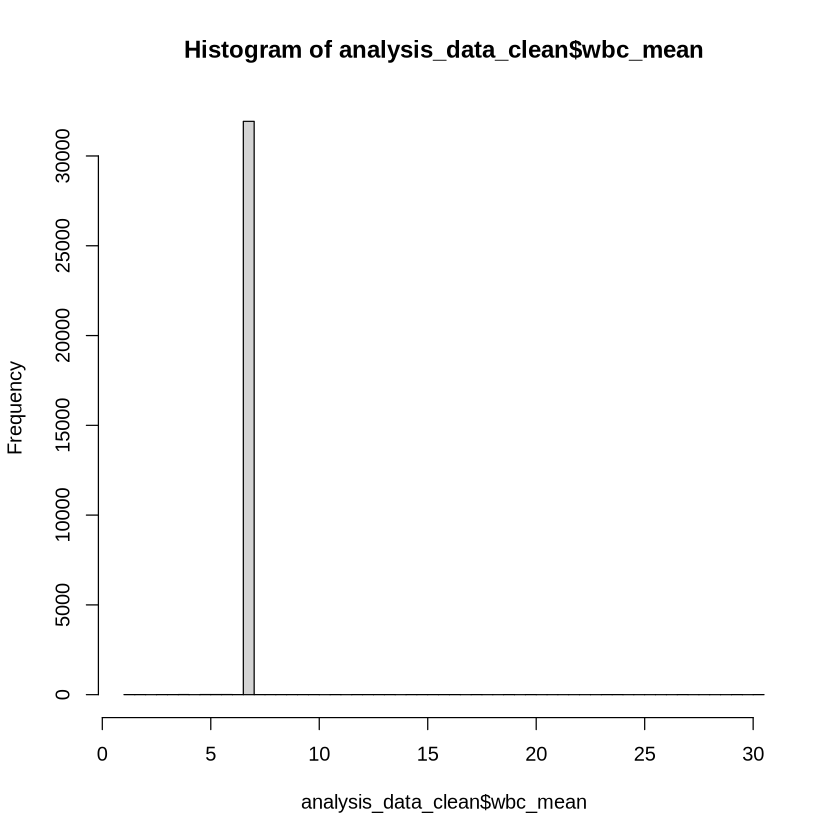

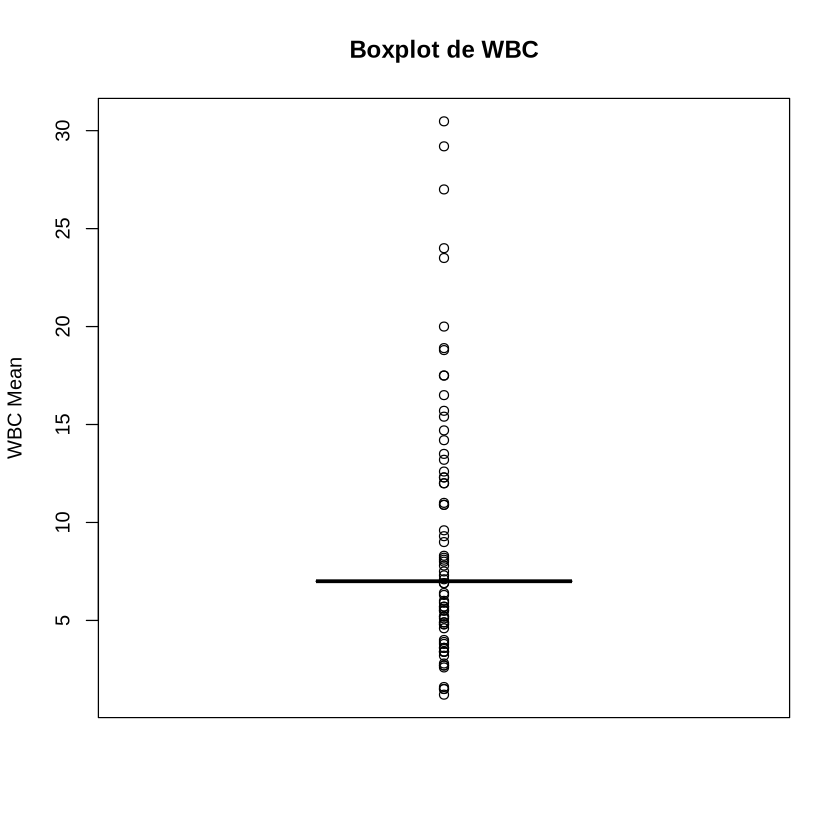

In [9]:
summary(analysis_data_clean$wbc_mean)
sd(analysis_data_clean$wbc_mean)
hist(analysis_data_clean$wbc_mean, breaks = 50)
boxplot(analysis_data_clean$wbc_mean, main = "Boxplot de WBC", ylab = "WBC Mean")

After cleaning the data and imputing missing values, the distribution of the white blood cell count (wbc_mean) was explored using descriptive statistics and a histogram to verify that imputation by median had not eliminated its variability. Although most values were concentrated around the median, the variable showed a standard deviation other than zero and clinically plausible maximum values, so it was kept in the model and interpreted with caution.

In [12]:
dim(analysis_data_clean)
str(analysis_data_clean)
colSums(is.na(analysis_data_clean))

[1] 32000    11

'data.frame':	32000 obs. of  11 variables:
 $ hospital_expire_flag: Factor w/ 2 levels "Survivor","Non-survivor": 1 1 1 2 1 2 1 1 1 1 ...
 $ age                 : num  76 48 66 41 50 72 40 47 51 90 ...
 $ gender              : Factor w/ 2 levels "F","M": 2 1 1 2 1 2 1 1 2 2 ...
 $ hr_mean             : num  111.8 89.2 84.2 92.5 85 ...
 $ map_mean            : num  75.7 85.3 84.5 98.8 71.4 ...
 $ rr_mean             : num  12.9 25.4 12.3 14.4 18 ...
 $ spo2_mean           : num  97.9 97.5 99.2 97.7 96.5 ...
 $ temp_mean           : num  98.2 98.3 97.7 98.7 98.3 ...
 $ lactate_mean        : num  4.87 1.85 1.85 2.33 1.85 ...
 $ creatinine_mean     : num  2.47 0.5 7.31 1.4 0.7 ...
 $ wbc_mean            : num  7 7 7 7 7 7 7 7 7 7 ...


hospital_expire_flag                  age               gender 
                   0                    0                    0 
             hr_mean             map_mean              rr_mean 
                   0                    0                    0 
           spo2_mean            temp_mean         lactate_mean 
                   0                    0                    0 
     creatinine_mean             wbc_mean 
                   0                    0

Before training the model:
* we need to verify there are no NA values left
* the variables have the correct type
* the N size is the expected one

In [13]:
table(analysis_data_clean$hospital_expire_flag)
prop.table(table(analysis_data_clean$hospital_expire_flag))


    Survivor Non-survivor 
       28493         3507 


    Survivor Non-survivor 
   0.8904062    0.1095938 

THe ouput is binary and it is correctly transformed to factor. The mortality is around 11%, which is the expected value.

In [14]:
# Check for multicollinearity
# We want to verify there are no repeated variables that may confuse the model
numeric_vars <- analysis_data_clean %>% select(all_of(vars_to_clean))
cor_matrix <- cor(numeric_vars, use = "complete.obs")
print(cor_matrix)


                    hr_mean     map_mean      rr_mean   spo2_mean    temp_mean
hr_mean          1.00000000  0.061963256  0.321737216 -0.11205994  0.239425438
map_mean         0.06196326  1.000000000 -0.009640663  0.04379231  0.069611262
rr_mean          0.32173722 -0.009640663  1.000000000 -0.30539138  0.119838839
spo2_mean       -0.11205994  0.043792305 -0.305391378  1.00000000  0.037810373
temp_mean        0.23942544  0.069611262  0.119838839  0.03781037  1.000000000
lactate_mean     0.15217812 -0.048081271  0.073487670 -0.02228506 -0.058325456
creatinine_mean -0.02527754 -0.054680656  0.058371515 -0.05751767 -0.082722835
wbc_mean         0.01845608  0.004269776  0.025189713 -0.01101815  0.007932372
                lactate_mean creatinine_mean     wbc_mean
hr_mean           0.15217812    -0.025277540  0.018456083
map_mean         -0.04808127    -0.054680656  0.004269776
rr_mean           0.07348767     0.058371515  0.025189713
spo2_mean        -0.02228506    -0.057517669 -0.011018154

**Interpretation of the Collinearity Matrix**

The presence of multicollinearity among the continuous predictor variables was evaluated using Pearson's correlation coefficient. The objective was to identify pairs of variables with a strong correlation ($|r| > 0.7$) that could introduce redundancy and instability into the logistic regression model.
The Dormann et al, 2013 paper (https://nsojournals.onlinelibrary.wiley.com/doi/10.1111/j.1600-0587.2012.07348.x) was used as a reference to set the threshold.

**Results**

* Absence of Collinearity: All correlation coefficients remained well below the critical threshold of 0.7. The maximum absolute value observed was 0.32 (between heart rate and respiratory rate).
* Conclusion: No variables need to be eliminated due to redundancy. All selected variables contribute independent information to the model.

**Physiological Observations**

Expected clinical associations were detected, although of moderate magnitude_

* HR_mean vs RR_mean ($r = 0.32$): Positive correlation. Physiologically consistent, as states of physiological stress (fever, sepsis, pain) tend to simultaneously elevate heart and respiratory rates.
* RR_mean vs SpO2_mean ($r = -0.30$): Negative correlation. This indicates that lower oxygen saturation increases respiratory rate (compensatory tachypnea), which is a typical defense mechanism against hypoxia.


In [15]:
#WEIGHTED GLM

# 1. Divide Train/Test
set.seed(123)
trainIndex <- createDataPartition(analysis_data_clean$hospital_expire_flag, p = .7, list = FALSE)
data_train <- analysis_data_clean[ trainIndex,]
data_test  <- analysis_data_clean[-trainIndex,]

# 2. Calculate weights so that the model pays attention to the deceased
n_total     <- nrow(data_train)
n_survivors <- sum(data_train$hospital_expire_flag == "Survivor")
n_deaths    <- sum(data_train$hospital_expire_flag == "Non-survivor")

# Weights formula: it penalized the errors in the minority class more heavily
weights_vector <- ifelse(data_train$hospital_expire_flag == "Non-survivor",
                        ((1/n_deaths) * 0.5) * n_total,
                        ((1/n_survivors) * 0.5) * n_total)
# 3. Train the model
model <- glm(hospital_expire_flag ~ age + gender + hr_mean + map_mean +
             rr_mean + spo2_mean + temp_mean + lactate_mean +
             creatinine_mean + wbc_mean,
             data = data_train,
             family = binomial,
             weights = weights_vector)

summary(model)

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”



Call:
glm(formula = hospital_expire_flag ~ age + gender + hr_mean + 
    map_mean + rr_mean + spo2_mean + temp_mean + lactate_mean + 
    creatinine_mean + wbc_mean, family = binomial, data = data_train, 
    weights = weights_vector)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)     -0.2860304  1.4354594  -0.199 0.842059    
age              0.0321351  0.0009870  32.559  < 2e-16 ***
genderM         -0.1110983  0.0300902  -3.692 0.000222 ***
hr_mean          0.0151537  0.0010308  14.700  < 2e-16 ***
map_mean         0.0003149  0.0015111   0.208 0.834937    
rr_mean          0.0921918  0.0039042  23.614  < 2e-16 ***
spo2_mean        0.0074923  0.0079949   0.937 0.348687    
temp_mean       -0.0731427  0.0127012  -5.759 8.47e-09 ***
lactate_mean     0.3774712  0.0142950  26.406  < 2e-16 ***
creatinine_mean  0.2665273  0.0127788  20.857  < 2e-16 ***
wbc_mean         0.0430743  0.0365507   1.178 0.238605    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.

The table above displays the raw coefficients ($\beta$) derived from the weighted logistic regression model.

1. Statistical Significance (Column Pr(>|z|)):
* Variables marked with three asterisks (***) exhibit extremely low p-values ($< 2 \times 10^{-16}$), indicating a robust statistical association with mortality.
* Significant Variables: Lactate, Creatinine, Age, Heart Rate, Respiratory Rate, Temperature, and Gender.
* Non-Significant Variables: Mean Arterial Pressure (MAP), White Blood Cells (WBC), and Oxygen Saturation (SpO2) showed no independent significance ($p > 0.05$) when adjusting for other markers.
  
2. Direction of Effect (Column Estimate):
* Positive Sign: Indicates that higher values are associated with an increased risk of mortality. This is clearly observed in Lactate (0.377), Creatinine (0.266), and Age (0.032).
* Negative Sign : Indicates that higher values are associated with decreased risk (or conversely, lower values with higher risk).
    * Temperature (-0.073): The negative coefficient implies that hypothermia (lower temperature) is associated with higher mortality.
    * Gender M (-0.111): With "Female" as the reference category, a negative value for "M" indicates that, after adjusting for severity, male gender presented a slightly lower baseline risk in this cohort.


In [16]:
# Summary of the Training and Test sets

# Training set
cat("--- TRAINING SET DISTRIBUTION ---\n")
train_counts <- table(data_train$hospital_expire_flag)
print(train_counts)
cat("Percentage:\n")
print(prop.table(train_counts) * 100)

cat("\n---------------------------------\n\n")

# Test set
cat("--- TEST SET DISTRIBUTION ---\n")
test_counts <- table(data_test$hospital_expire_flag)
print(test_counts)
cat("Percentage:\n")
print(prop.table(test_counts) * 100)

# 3. Verificación del total
cat("\nTotal N:", nrow(data_train) + nrow(data_test), "\n")

--- TRAINING SET DISTRIBUTION ---

    Survivor Non-survivor 
       19946         2455 
Percentage:

    Survivor Non-survivor 
    89.04067     10.95933 

---------------------------------

--- TEST SET DISTRIBUTION ---

    Survivor Non-survivor 
        8547         1052 
Percentage:

    Survivor Non-survivor 
    89.04053     10.95947 

Total N: 32000 


In [14]:
# Obtain Odds Ratios and the CI (95%)
or_table <- exp(cbind(OR = coef(model), confint(model)))
print(round(or_table, 3))


Waiting for profiling to be done...

Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial glm!”
Warning message in eval(family$initialize):
“non-integer #successes in a binomial g

                   OR 2.5 % 97.5 %
(Intercept)     0.751 0.045 12.515
age             1.033 1.031  1.035
genderM         0.895 0.844  0.949
hr_mean         1.015 1.013  1.017
map_mean        1.000 0.997  1.003
rr_mean         1.097 1.088  1.105
spo2_mean       1.008 0.992  1.023
temp_mean       0.929 0.907  0.953
lactate_mean    1.459 1.419  1.500
creatinine_mean 1.305 1.273  1.339
wbc_mean        1.044 0.976  1.130


The Odds Ratios confirm the direction and magnitude of the effect for each variable:

* Lactate (OR 1.46): This is the strongest independent predictor. For every 1 mmol/L increase in lactate, the odds of mortality increase by 45.9%.
* Creatinine (OR 1.31): Renal dysfunction is a critical factor; each additional mg/dL increases the risk by 30.5%.
* Respiratory Rate (OR 1.10): Tachypnea is an early warning sign, associated with a 9.7% risk increase per unit.
* Temperature (OR 0.93): The OR < 1 indicates an inverse relationship. Hypothermia is associated with higher mortality (risk increases as temperature drops).
* Gender (OR 0.90): Being male (genderM) was associated with a slightly lower adjusted risk (~10% lower) compared to females in this cohort.
* Non-Significant Variables: The 95% Confidence Intervals for MAP, SpO2, and WBC cross the value of 1.0 (e.g., WBC ranges from 0.98 to 1.13). This confirms that, in this multivariate model, they do not provide additional predictive power beyond markers like lactate and creatinine.

In [15]:
# Clinical evaluation

# Predictions
pred_prob <- predict(model, newdata = data_test, type = "response")
# Convert probability to a class, Yes > 50% risk -> we predict death
pred_class <- ifelse(pred_prob > 0.5, "Non-survivor", "Survivor")
pred_class <- factor(pred_class, levels = c("Survivor", "Non-survivor"))

# confusion matrix
conf_matrix <- confusionMatrix(pred_class, data_test$hospital_expire_flag, positive = "Non-survivor")

print(conf_matrix) #sensisity ***


Confusion Matrix and Statistics

              Reference
Prediction     Survivor Non-survivor
  Survivor         6032          406
  Non-survivor     2515          646
                                          
               Accuracy : 0.6957          
                 95% CI : (0.6864, 0.7049)
    No Information Rate : 0.8904          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1702          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.6141          
            Specificity : 0.7057          
         Pos Pred Value : 0.2044          
         Neg Pred Value : 0.9369          
             Prevalence : 0.1096          
         Detection Rate : 0.0673          
   Detection Prevalence : 0.3293          
      Balanced Accuracy : 0.6599          
                                          
       'Positiv

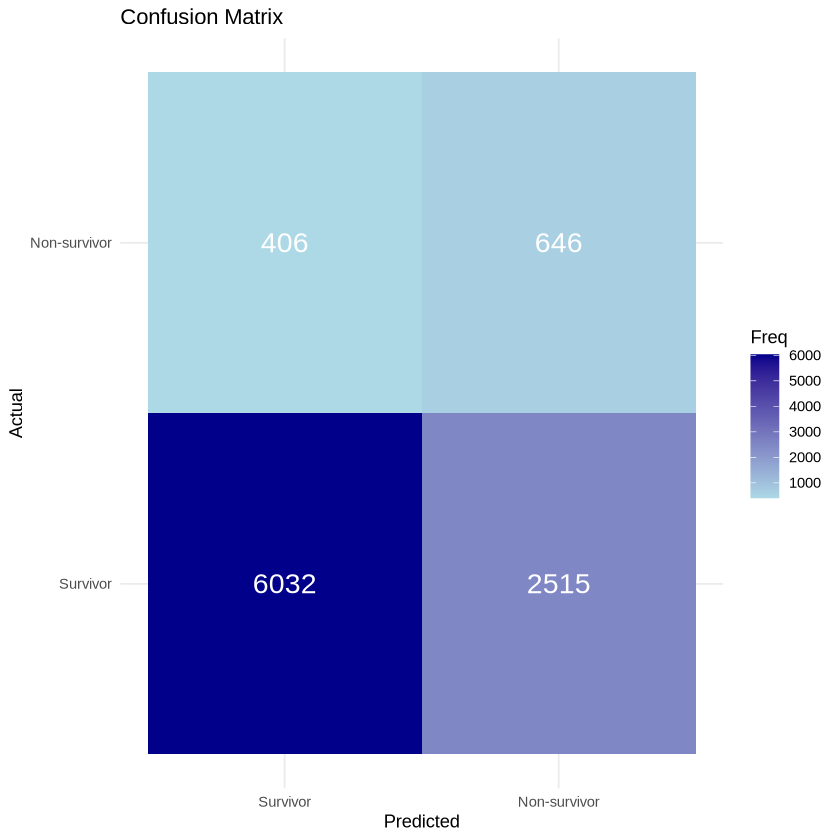

In [32]:
# Extract the table for the confusion matrix
cm_plot_data <- as.data.frame(conf_matrix$table)
colnames(cm_plot_data) <- c("Prediction", "Reference", "Freq")

# Force the order: survivor first, and non-survivor next
cm_plot_data$Prediction <- factor(cm_plot_data$Prediction, levels = c("Survivor", "Non-survivor"))
cm_plot_data$Reference <- factor(cm_plot_data$Reference, levels = c("Survivor", "Non-survivor"))

# Plot
plot_cm <- ggplot(cm_plot_data, aes(x = Prediction, y = Reference, fill = Freq)) +
    geom_tile() +
    geom_text(aes(label = Freq), color = "white", size = 6) +
    scale_fill_gradient(low = "lightblue", high = "darkblue") +
    theme_minimal() +
    labs(title = "Confusion Matrix", x = "Predicted", y = "Actual")

print(plot_cm)

ggsave("confusion_matrix.jpg", plot = plot_cm, width = 6, height = 5, dpi = 300)


By prioritizing the detection of the minority class (non-survivors) through the use of class weights, the model performance was optimized for clinical safety. The results on the resting set (n = 9599) demonstrate the following:

* Sensitivity (Recall): 61.4%. The model correctly identified 646/1052 real deaths in the test set. This represents a critical improvement compared to an unweighted model.
* Negative Predictive Value (NPV) of 93.7%: The model proved to be highly reliable for identifying survivors. Specifically, when the model predicted survival, it was correct in 6,032 out of 6,438 cases, meaning the probability of a "false reassurance" (missing a death) is very low.
* Clinical Trade-off: In exchange for increased sensitivity, the model accepts a higher False Positive Rate(n = 2515), resulting in a Precision(PPV)  of 20.4%. In a clinical  context, this is acceptable because, it is preferable to over-monitor a patient who eventually survives than to overlook a patient who will eventually die.
* Accuracy vs Balanced Accuracy(69.6%): While the overall Accuracy was 69.6%, the Balanced Accuracy of 66% provides a more realistic reflection of the performance of the model, because it accounts for the successfull classification of both survivors and non survivors despite the class imbalance.


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = Survivor, case = Non-survivor

Setting direction: controls < cases



[1] "Area Under the Curve (AUC): 0.7255"


png 
  2

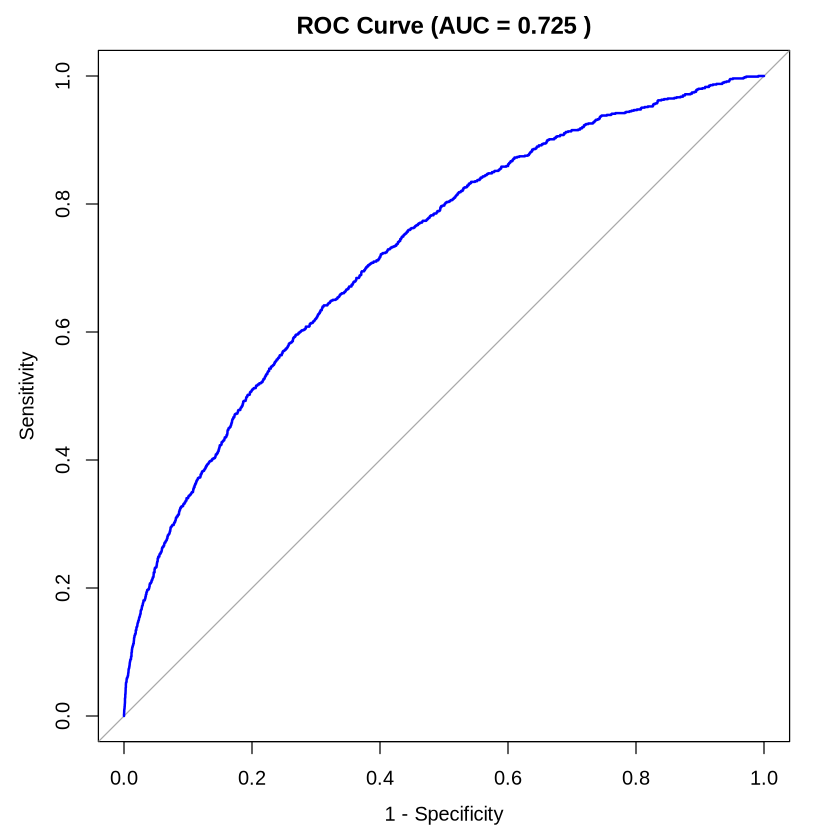

In [33]:
# Evaluation of the model (ROC and AUC)
library(pROC)
# ROC curve
roc_eval <- roc(
  response = data_test$hospital_expire_flag,
  predictor = pred_prob
)

# Calculate and show AUC value
auc_value <- auc(roc_eval)
print(paste("Area Under the Curve (AUC):", round(auc_value, 4)))
# Plot the curve in the notebook
plot(roc_eval,
     main = paste("ROC Curve (AUC =", round(auc_value, 3), ")"),
     col = "blue",
     lwd = 2, legacy.axes = TRUE)

# Save the plot
png("ROC_Curve.png", width=2000, height=2000, res=300)
plot(roc_eval, main = paste("ROC Curve (AUC =", round(auc_value, 3), ")"), col = "blue", lwd = 2, legacy.axes = TRUE)
dev.off()

We evaluated how well the model distinguishes between patients who survived and those who did not using AUC. In the test set the model achieved an AUC of 0.725. This performance, combined with a Sensitivity of 61.4% and a Negative Predictive Value of 93.7%, suggest that the model is clinically usefull as a screening tool.

Clinical conclusion: The results confirm that hyperlactatemia and renal dysfunction, together with advanced age and altered basic vital signs (temperature and respiratory rate), are robust independent predictors. The proposed model effectively identifies more than 60% of patients at risk of imminent death while maintaining a low false negative rate, which could facilitate the early activation of life support protocols in critically ill patients.